In [6]:
# ======================
# MPPT P&O 시뮬레이션 초기 조건
# ======================
# - 초기 전압: 15.0 V
# - 스텝 크기: 0.5 V
# - PV 기준값: V_oc = 37.0 V, I_sc = 8.5 A
# - 일사량 변화:
#   0~3 s   -> 1000 W/m^2
#   3~6 s   -> 500 W/m^2
#   6~10 s  -> 1000 W/m^2
# - 비교 조건: 샘플링 시간 dt = 0.01 s, 0.05 s
# - 확인 항목: 전압 추종, 전력 변화

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# ==============
# 1. 초기 조건
# ==============
V_init = 15.0
delta_V = 0.5

V_oc = 37.0
I_sc = 8.5

In [9]:
# ======================
# 2. 일사량 함수
# ======================
def irradiance(t):
    if t < 3:
        return 1.0
    elif t < 6:
        return 0.5
    else:
        return 1.0

In [10]:
# ======================
# 3. PV 모델
# ======================
# 이 함수는 "현재 전압 V"와 "현재 일사량 비율 G"를 입력받아서
# 그때의 전류 I와 전력 P를 계산해주는 역할을 한다.
#
# 실제 태양광 패널은 훨씬 복잡하지만,
# 이번에는 P&O 알고리즘의 흐름을 이해하는 것이 목적이므로
# 단순화한 식을 사용한다.
def pv_model(V, G):
    # 전류 I를 계산하는 부분이다.
    #
    # I_sc * G :
    #   기본 최대 전류(Isc)에 일사량 비율 G를 곱해서
    #   일사량이 줄면 전류도 같이 줄어들도록 만든다.
    #
    # (1 - (V / V_oc)**2) :
    #   전압이 커질수록 전류가 줄어들도록 만든 단순한 형태의 식이다.
    #   V가 0에 가까우면 이 값은 1에 가깝고,
    #   V가 Voc에 가까워질수록 0에 가까워진다.
    I = I_sc * G * (1 - (V / V_oc)**2)

    # 위 식으로 계산했을 때 아주 높은 전압에서는
    # 전류가 음수가 나올 수도 있다.
    # 실제로는 음의 전류로 두기보다 0으로 막아주는 것이 자연스럽기 때문에,
    # 음수가 나오면 0으로 고정한다.
    if I < 0:
        I = 0

    # 전력은 전압 × 전류 이므로 P = V * I 로 계산한다.
    P = V * I

    # 계산된 전류 I와 전력 P를 함수 밖으로 돌려준다.
    return I, P

In [11]:
# ======================
# 4. P&O 알고리즘용 변수
# ======================

# Vref:
# 알고리즘이 현재 목표로 삼는 전압이다.
# 처음에는 문제 조건대로 초기 전압 15V에서 시작한다.
Vref = V_init

# prev_P:
# 바로 이전 순간의 전력을 저장하는 변수이다.
# 현재 전력과 이전 전력을 비교하기 위해 필요하다.
prev_P = 0.0

# direction:
# 전압을 어느 방향으로 움직일지 정하는 변수이다.
#  1  -> 전압 증가 방향
# -1  -> 전압 감소 방향
# 처음에는 전압을 올리는 방향으로 시작한다.
direction = 1

In [12]:
# ======================
# 4. P&O 알고리즘
# ======================
Vref = V_init
prev_P = 0
direction = 1

def PO(V, I):
    global Vref, prev_P, direction

    P = V * I

    if P > prev_P:
        Vref = Vref + direction * delta_V
    else:
        direction = -direction
        Vref = Vref + direction * delta_V

    # 전압 제한
    if Vref > V_oc:
        Vref = V_oc
    if Vref < 0:
        Vref = 0

    prev_P = P

    return Vref

In [13]:
# ======================
# 5. 시뮬레이션 함수
# ======================
def run_simulation(dt):
    time = np.arange(0, 10, dt)

    V_arr = []
    I_arr = []
    P_arr = []
    G_arr = []

    global Vref, prev_P, direction

    # 초기화
    Vref = V_init
    prev_P = 0
    direction = 1

    for t in time:
        G = irradiance(t)

        V = Vref
        I, P = pv_model(V, G)

        Vref = PO(V, I)

        V_arr.append(V)
        I_arr.append(I)
        P_arr.append(P)
        G_arr.append(G)

    return time, V_arr, P_arr, G_arr

In [14]:
# ======================
# 6. 두 조건 실행
# ======================
t1, V1, P1, G1 = run_simulation(0.01)
t2, V2, P2, G2 = run_simulation(0.05)

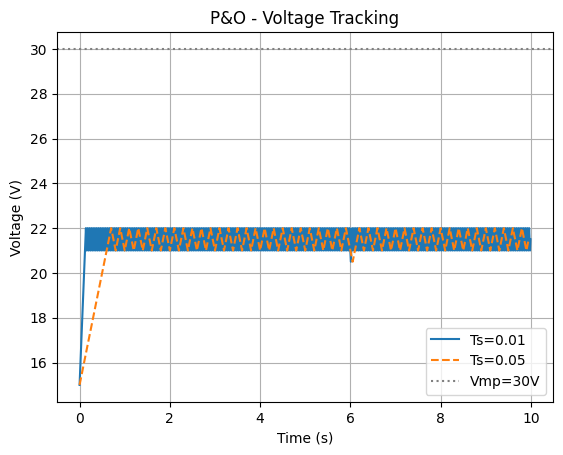

In [15]:
# ======================
# 7. 그래프 (Voltage)
# ======================
plt.figure()
plt.plot(t1, V1, label='Ts=0.01')
plt.plot(t2, V2, label='Ts=0.05', linestyle='--')
plt.axhline(30, color='gray', linestyle=':', label='Vmp=30V')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('P&O - Voltage Tracking')
plt.legend()
plt.grid()
plt.show()

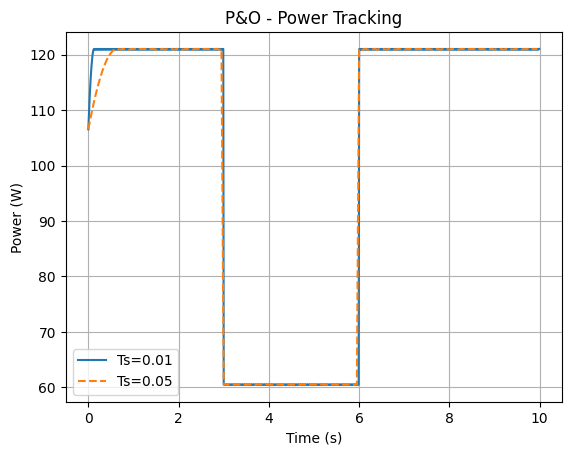

In [16]:
# ======================
# 8. 그래프 (Power)
# ======================
plt.figure()
plt.plot(t1, P1, label='Ts=0.01')
plt.plot(t2, P2, label='Ts=0.05', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Power (W)')
plt.title('P&O - Power Tracking')
plt.legend()
plt.grid()
plt.show()